# Plot AOI time series mean AGB

### Import required packages

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import snowflake.connector

### Connect to the database and fetch the AOI data
- Note that the environment variables need to be set with the database credentials. 
- Replace 'my-aoi-id' with your AOI ID. 
- For Planet, dividing by 0.476 transforms from aboveground biomass carbon to total aboveground biomass.

In [2]:
with snowflake.connector.connect(
    account=os.environ["SNOWFLAKE_ACCOUNT"],
    warehouse=os.environ["SNOWFLAKE_WAREHOUSE"],
    database=os.environ["SNOWFLAKE_DATABASE"],
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ["SNOWFLAKE_PASSWORD"],
) as conn:

    cur = conn.cursor().execute('''
        select
            year,
            avg(c.aboveground_biomass_stock) as chloris_agb,
            avg(k.living_aboveground_biomass) as kanop_agb,
            avg(p.aboveground_live_carbon_density / 0.476) as planet_agb,
            avg((c.aboveground_biomass_stock + k.living_aboveground_biomass + (p.aboveground_live_carbon_density / 0.476)) / 3) as mean_agb
        from chloris.aboveground_biomass_stock_and_change c
        join kanop.standard k using (aoi_id, year, x, y)
        join planet.forest_carbon_diligence p using (aoi_id, year, x, y)
        where 
            aoi_id = 'my-aoi-id' and
            year >= 2014 and year <= 2022 
        group by year
        order by year
        ;
    ''')

    df = cur.fetch_pandas_all()

### Plot chart
Plot time series chart with mean AGB data from three providers and total mean per year.

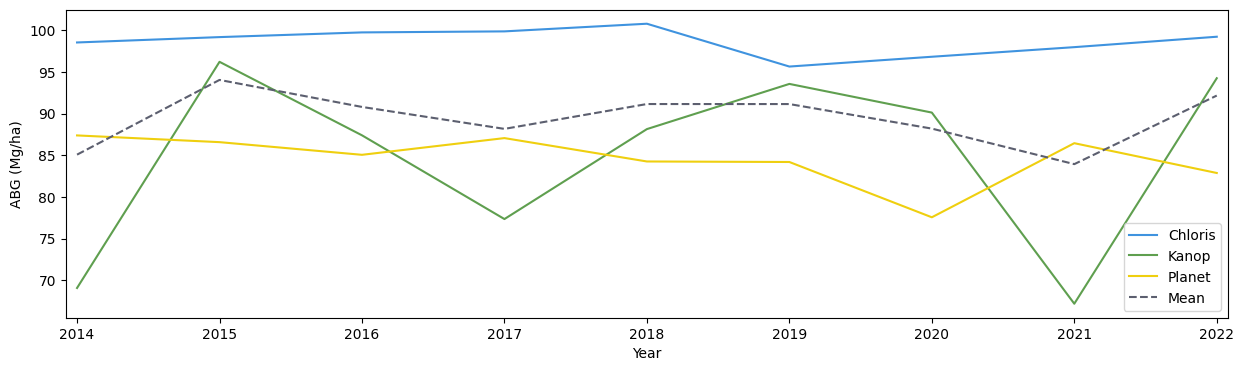

In [3]:
years = df["YEAR"]

plt.figure(figsize=(15, 4))
plt.margins(x=0.01)

plt.xlabel("Year")
plt.ylabel("ABG (Mg/ha)")

plt.plot(years, df["CHLORIS_AGB"], label="Chloris", color="#3F93DF")
plt.plot(years, df["KANOP_AGB"], label="Kanop", color="#5F9F4F")
plt.plot(years, df["PLANET_AGB"], label="Planet", color="#EFCF0F")
plt.plot(years, df["MEAN_AGB"], label="Mean", color="#5C5F6F", linestyle="--")

plt.legend(loc="lower right")

plt.show()